# Chapter 3: Computational Methods for Optimization


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 3.1-3.4: numerical root finding, random search, Newton's method in several variables, linear programming, and integer programming.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 3.1 One-variable optimization: graph globally, solve locally

The chapter revisits the pig problem with exponential weight growth

\[
w(t)=200e^{0.025t}.
\]

The derivative equation has no convenient elementary solution, so we first locate the optimum graphically and then use Newton's method.


In [2]:
from scipy import optimize

x = sp.symbols("x", real=True)
c_growth = sp.Rational(25, 1000)
nonlinear_profit = (sp.Rational(65, 100) - sp.Rational(1, 100) * x) * 200 * sp.exp(c_growth * x) - sp.Rational(45, 100) * x
F = sp.diff(nonlinear_profit, x)
dF = sp.diff(F, x)

profit_fn = sp.lambdify(x, nonlinear_profit, "numpy")
F_fn = sp.lambdify(x, F, "numpy")
dF_fn = sp.lambdify(x, dF, "numpy")

def newton_scalar(function, derivative, x0, iterations=10):
    values = [float(x0)]
    current = float(x0)
    for _ in range(iterations):
        slope = derivative(current)
        if abs(slope) < 1e-14:
            raise ZeroDivisionError("Newton derivative became too small")
        current = current - function(current) / slope
        values.append(float(current))
    return np.array(values)

newton_path = newton_scalar(F_fn, dF_fn, 19.5, iterations=8)
x_opt = newton_path[-1]
y_opt = profit_fn(x_opt)

display(pd.DataFrame({"iteration": np.arange(len(newton_path)), "x": newton_path, "F(x)": F_fn(newton_path)}))
print(f"Optimum: x={x_opt:.6f} days, profit=${y_opt:.6f}")
assert np.isclose(x_opt, 19.468159, atol=1e-5)


,iteration,x,F(x)
0,0,19.500000,-2.233855e-03
1,1,19.468187,-1.917488e-06
2,2,19.468159,-1.416922e-12
3,3,19.468159,6.106227e-16
4,4,19.468159,-7.216450e-16
5,5,19.468159,6.106227e-16
6,6,19.468159,-2.775558e-16
7,7,19.468159,6.106227e-16
8,8,19.468159,-7.216450e-16


Optimum: x=19.468159 days, profit=$139.394923


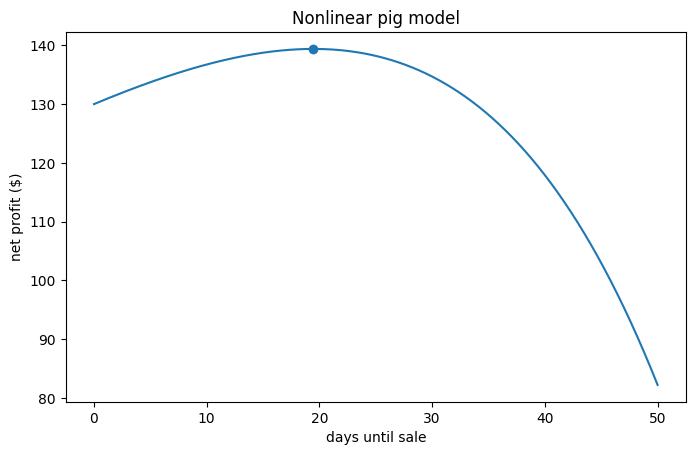

In [3]:
x_grid = np.linspace(0, 50, 600)
plt.plot(x_grid, profit_fn(x_grid))
plt.scatter([x_opt], [y_opt], zorder=3)
plt.xlabel("days until sale")
plt.ylabel("net profit ($)")
plt.title("Nonlinear pig model")
plt.show()


## 3.2 Multivariable optimization: facility location by random search

The fire-station example aggregates emergency-call frequencies into nine two-mile sectors. Average response time is a weighted nonlinear function of station location. Random search gives a global approximation; a local optimizer refines it.


In [4]:
centers = np.array([
    [1, 5], [3, 5], [5, 5],
    [1, 3], [3, 3], [5, 3],
    [1, 1], [3, 1], [5, 1],
], dtype=float)
call_weights = np.array([6, 8, 8, 21, 6, 3, 18, 8, 6], dtype=float)
assert call_weights.sum() == 84

def response_time(location):
    distances = np.linalg.norm(centers - np.asarray(location), axis=1)
    return 3.2 + 1.7 * np.average(distances**0.91, weights=call_weights)

random_points = rng.uniform(0, 6, size=(1_000, 2))
random_values = np.array([response_time(point) for point in random_points])
best_index = np.argmin(random_values)
random_best = random_points[best_index]

local = optimize.minimize(
    response_time,
    x0=random_best,
    bounds=[(0, 6), (0, 6)],
    method="Nelder-Mead",
    options={"xatol": 1e-12, "fatol": 1e-12, "maxiter": 10_000},
)

facility_results = pd.DataFrame({
    "method": ["random search (N=1000)", "local refinement"],
    "x": [random_best[0], local.x[0]],
    "y": [random_best[1], local.x[1]],
    "average response (min)": [random_values[best_index], local.fun],
})
display(facility_results)
assert local.success


,method,x,y,average response (min)
0,random search (N=1000),1.680207,2.620506,6.468827
1,local refinement,1.616488,2.765907,6.462980


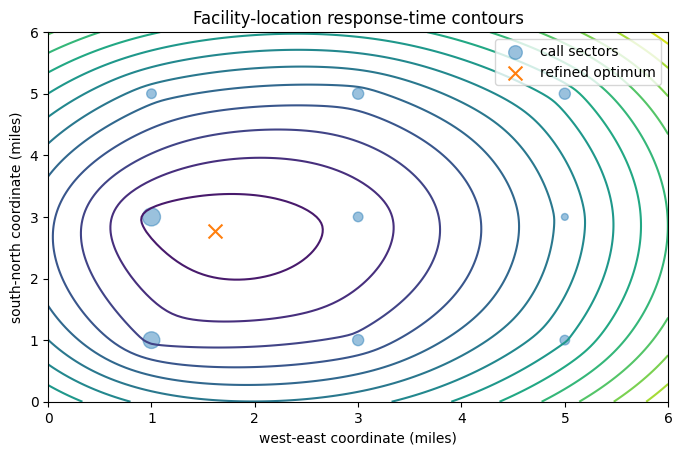

In [5]:
grid = np.linspace(0, 6, 121)
GX, GY = np.meshgrid(grid, grid)
GZ = np.array([[response_time((gx, gy)) for gx in grid] for gy in grid])

plt.contour(GX, GY, GZ, levels=14)
plt.scatter(centers[:, 0], centers[:, 1], s=call_weights * 8, alpha=0.45, label="call sectors")
plt.scatter([local.x[0]], [local.x[1]], marker="x", s=100, label="refined optimum")
plt.xlabel("west-east coordinate (miles)")
plt.ylabel("south-north coordinate (miles)")
plt.title("Facility-location response-time contours")
plt.legend()
plt.show()


## Newton's method in two variables: lawn-chair production

The two product-price curves produce a nonlinear profit surface. We solve \(\nabla f=0\) with a hand-written multivariable Newton iteration using the Hessian.


In [6]:
xc, yc = sp.symbols("xc yc", positive=True, real=True)
chair_profit = (
    xc * (10 + 31 * xc**sp.Rational(-1, 2) + sp.Rational(13, 10) * yc**sp.Rational(-1, 5)) - 18 * xc
    + yc * (5 + 15 * yc**sp.Rational(-2, 5) + sp.Rational(8, 10) * xc**sp.Rational(-2, 25)) - 10 * yc
)
chair_grad = sp.Matrix([sp.diff(chair_profit, xc), sp.diff(chair_profit, yc)])
chair_hessian = sp.hessian(chair_profit, (xc, yc))
chair_grad_fn = sp.lambdify((xc, yc), chair_grad, "numpy")
chair_hessian_fn = sp.lambdify((xc, yc), chair_hessian, "numpy")
chair_profit_fn = sp.lambdify((xc, yc), chair_profit, "numpy")

def newton_system(gradient, hessian, initial, iterations=12):
    point = np.asarray(initial, dtype=float)
    history = [point.copy()]
    for _ in range(iterations):
        step = np.linalg.solve(np.asarray(hessian(*point), dtype=float), np.asarray(gradient(*point), dtype=float).reshape(-1))
        point = point - step
        if np.any(point <= 0):
            raise ValueError("Newton iteration left the positive state space")
        history.append(point.copy())
    return np.array(history)

chair_path = newton_system(chair_grad_fn, chair_hessian_fn, [5.0, 5.0], iterations=10)
chair_opt = chair_path[-1]
chair_value = float(chair_profit_fn(*chair_opt))

display(pd.DataFrame(chair_path, columns=["wood-frame x", "aluminum-frame y"]).tail())
print(f"Optimum production: {chair_opt[0]:.5f}, {chair_opt[1]:.5f}; profit=${chair_value:.4f}/day")
assert np.allclose(chair_opt, [4.68959, 5.85199], atol=2e-5)


,wood-frame x,aluminum-frame y
6,4.689585,5.851994
7,4.689585,5.851994
8,4.689585,5.851994
9,4.689585,5.851994
10,4.689585,5.851994


Optimum production: 4.68959, 5.85199; profit=$52.0727/day


## 3.3 Linear programming: the farm model

Maximize crop yield subject to irrigation, labor, and land constraints. SciPy's HiGHS interface also reports dual marginals, the computational version of shadow prices.

This model has an **optimal edge**, not a unique optimizer: the corn-wheat and corn-oats corner points earn the same yield, and every convex combination between them is optimal. A linear-programming solver is therefore free to return either endpoint (or, less commonly, another point on the edge).

In [7]:
from scipy.optimize import Bounds, LinearConstraint, linprog, milp

crop_names = ["corn", "wheat", "oats"]
profit_per_acre = np.array([400.0, 200.0, 250.0])
A_ub = np.array([
    [3.0, 1.0, 1.5],
    [0.8, 0.2, 0.3],
    [1.0, 1.0, 1.0],
])
b_ub = np.array([1_000.0, 300.0, 625.0])

lp = linprog(-profit_per_acre, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method="highs")
shadow_prices = -np.asarray(lp.ineqlin.marginals)

lp_table = pd.DataFrame({
    "crop": crop_names,
    "acres": lp.x,
    "yield per acre": profit_per_acre,
})
display(lp_table)
display(pd.DataFrame({
    "resource": ["irrigation", "labor", "land"],
    "used": A_ub @ lp.x,
    "available": b_ub,
    "slack": lp.ineqlin.residual,
    "shadow price": shadow_prices,
}))
print(f"Maximum expected yield: ${-lp.fun:,.2f}")

# The textbook's corn-wheat point and the equally optimal corn-oats point are
# endpoints of the same optimal face. HiGHS may select either endpoint.
optimal_endpoints = pd.DataFrame(
    [
        [187.5, 437.5, 0.0],
        [125 / 3, 0.0, 1750 / 3],
    ],
    index=["corn-wheat endpoint", "corn-oats endpoint"],
    columns=crop_names,
)
optimal_endpoints["yield"] = optimal_endpoints.to_numpy() @ profit_per_acre
display(optimal_endpoints)

assert lp.success
assert np.all(lp.x >= -1e-9)
assert np.all(A_ub @ lp.x <= b_ub + 1e-7)
assert np.isclose(-lp.fun, 162_500.0, atol=1e-7)
assert np.allclose(A_ub[[0, 2]] @ lp.x, b_ub[[0, 2]], atol=1e-7)


,crop,acres,yield per acre
0,corn,41.666667,400.0
1,wheat,0.000000,200.0
2,oats,583.333333,250.0


,resource,used,available,slack,shadow price
0,irrigation,1000.000000,1000.0,0.000000,100.0
1,labor,208.333333,300.0,91.666667,0.0
2,land,625.000000,625.0,0.000000,100.0


Maximum expected yield: $162,500.00


,corn,wheat,oats,yield
corn-wheat endpoint,187.500000,437.5,0.000000,162500.0
corn-oats endpoint,41.666667,0.0,583.333333,162500.0


## 3.4 Integer programming: whole plots

The modified farm has five 120-acre plots and one 25-acre plot. Every plot receives only one crop, so all six decision variables are integers. The LP relaxation no longer tells the whole story, because apparently land has declined to cooperate with fractional bookkeeping.


In [8]:
import itertools

integer_profit = np.array([48_000, 24_000, 30_000, 10_000, 5_000, 6_250], dtype=float)
integer_A = np.array([
    [375, 125, 187.5, 75, 25, 37.5],
    [100, 25, 37.5, 20, 5, 7.5],
    [1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 1],
], dtype=float)
integer_b = np.array([1_000, 300, 5, 1], dtype=float)

ip = milp(
    c=-integer_profit,
    integrality=np.ones(6),
    bounds=Bounds(np.zeros(6), np.full(6, np.inf)),
    constraints=LinearConstraint(integer_A, -np.inf, integer_b),
    options={"time_limit": 30},
)

integer_names = [
    "120-acre corn", "120-acre wheat", "120-acre oats",
    "25-acre corn", "25-acre wheat", "25-acre oats",
]
ip_table = pd.DataFrame({"decision": integer_names, "number of plots": np.rint(ip.x).astype(int)})
display(ip_table)
print(f"Integer optimum yield: ${-ip.fun:,.2f}")
print(f"Continuous optimum yield: ${-lp.fun:,.2f}")
print(f"Discretization gap: ${(-lp.fun) - (-ip.fun):,.2f}")

# This small model can be exhaustively enumerated to verify the MILP result and
# expose non-uniqueness that a single solver output would otherwise hide.
feasible_integer_points = []
for large_plots in itertools.product(range(6), repeat=3):
    if sum(large_plots) > 5:
        continue
    for small_plots in itertools.product(range(2), repeat=3):
        if sum(small_plots) > 1:
            continue
        point = np.array(large_plots + small_plots, dtype=float)
        if np.all(integer_A @ point <= integer_b + 1e-9):
            feasible_integer_points.append((float(integer_profit @ point), point.astype(int)))

verified_optimum = max(value for value, _ in feasible_integer_points)
all_optima = [point for value, point in feasible_integer_points if np.isclose(value, verified_optimum)]
display(pd.DataFrame(all_optima, columns=integer_names).assign(yield_dollars=verified_optimum))

assert ip.success
assert np.isclose(-ip.fun, 156_250.0, atol=1e-7)
assert np.isclose(-ip.fun, verified_optimum, atol=1e-7)
assert any(np.array_equal(np.rint(ip.x).astype(int), point) for point in all_optima)


,decision,number of plots
0,120-acre corn,1
1,120-acre wheat,3
2,120-acre oats,1
3,25-acre corn,0
4,25-acre wheat,0
5,25-acre oats,1


Integer optimum yield: $156,250.00
Continuous optimum yield: $162,500.00
Discretization gap: $6,250.00


,120-acre corn,120-acre wheat,120-acre oats,25-acre corn,25-acre wheat,25-acre oats,yield_dollars
0,0,0,5,0,0,1,156250.0
1,1,3,1,0,0,1,156250.0


## Chapter checkpoint

A robust computational workflow uses a coarse global method to locate promising regions, a fast local method to refine a solution, and explicit verification. Linear programming supplies dual information almost for free; integer programming does not, because its objective value changes in jumps rather than smoothly.
